In [8]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy.stats as stats
from sklearn.tree import DecisionTreeRegressor

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

sns.set()

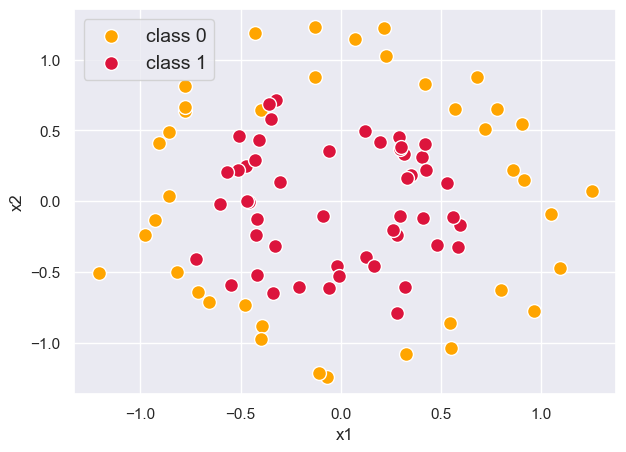

In [9]:
import sklearn.datasets as datasets
from matplotlib.colors import ListedColormap

data = datasets.make_circles(n_samples=100, factor=0.5, noise=0.15, random_state=0)
x, y = data[0], data[1]

# make it imbalance
idx = np.sort(np.append(np.where(y != 0)[0], np.where(y == 0)[0][:-10]))
x, y = x[idx], y[idx]

plt.figure(figsize=(7, 5))
plt.scatter(x[y==0, 0], x[y==0, 1], c='orange', edgecolors='w', s=100, label='class 0')
plt.scatter(x[y==1, 0], x[y==1, 1], c='crimson', edgecolors='w', s=100, label='class 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(fontsize=14)
plt.show()

In [10]:
c_scale = [[0, "rgb(247, 168, 84)"], [1, "rgb(209, 0, 0)"]]

def create_scatter(x, y, plot_type):
    
    return go.Scatter3d(
                x=x[:, 0], y=x[:, 1], z=y,
                mode="markers",
                marker=dict(
                    size=6,
                    color=y,
                    colorscale=c_scale if plot_type == "pred" else "Blugrn",
                    line=dict(width=4, color="White"),
                ),
            )

def format_plot(fig):
  return fig.update_layout(
      scene=dict(
          xaxis_title="x1", 
          yaxis_title="x2", 
          zaxis_title="y"
      ),
      height=400,
      width=600,
      margin=dict(l=10, r=10, t=40, b=20),
  )

fig = go.Figure()
fig.add_trace(create_scatter(x, y, "pred"))
fig = format_plot(fig)
fig.show()

In [11]:
# creating mesh data to visualize prediction planes
x1_min, x1_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
x2_min, x2_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5

h = 0.02  # step size in the mesh
x1_mesh, x2_mesh = np.meshgrid(np.arange(x1_min, x1_max, h), np.arange(x2_min, x2_max, h))

In [12]:
def create_surface(x1, x2, y, plot_type):
    
    return go.Surface(x=x1, y=x2, z=y, 
                      showscale=False, 
                      opacity=0.5, 
                      colorscale="Peach" if plot_type == "pred" else "Tealgrn",
                      )

In [13]:
p = y.mean()

fig = go.Figure()
fig.add_trace(create_scatter(x, y, "pred"))
fig.add_trace(create_surface(x1_mesh, x2_mesh, np.full(x1_mesh.shape, p), "pred"))
fig = format_plot(fig)
fig.show()

In [14]:
def create_residual_lines(x, y, pred):
    
    #create the coordinate list for the lines
    x_list, y_list, z_list = [], [], []
    for i in range(len(x)):
        x_list.extend([x[i, 0], x[i, 0], None])
        y_list.extend([x[i, 1], x[i, 1], None])
        z_list.extend([y[i], pred[i], None])

    return go.Scatter3d(x=x_list, 
                         y=y_list, 
                         z=z_list, 
                         mode='lines',
                         line=dict(
                             color='brown',
                             width=5
                         ))


In [15]:
ig = go.Figure()
fig.add_trace(create_scatter(x, y, "pred"))
fig.add_trace(create_surface(x1_mesh, x2_mesh, np.full(x1_mesh.shape, p), "pred"))
fig.add_trace(create_residual_lines(x, y, np.full(y.shape, p)))
fig = format_plot(fig)
fig.update_layout(showlegend=False)
fig.show()